# Cross-Validation Trap Lab

## "Everyone knows CV can lie to you. Almost nobody measures by how much."

**Standalone notebook.** It generates its own data and defines every function it
uses. No install, no imports from the project package, nothing written to disk.
About 2 minutes top to bottom, 4 charts.

### The problem

You run 5-fold CV and get 0.743. You ship. Reality returns 0.716.

The usual advice about that gap is a list of things to avoid: do not fit your
scaler before the split, group your folds, respect time. All correct. None of it
tells you **which** mistake cost you the 0.027, or whether your careful new
number is right either.

Nobody answers that because **on real data you never see the truth**. A CV score
estimates something you cannot observe.

So in this notebook it is observable. A synthetic panel is split so one part is
never touched until the end, and every scheme is scored by one subtraction:

$$\text{optimism} = \text{cv\_auc} - \text{truth}$$

Positive means the scheme flattered the model.

### Contents

1. [The panel, and what was planted in it](#s1)
2. [The truth, defined once](#s2)
3. [The structural traps: groups and time](#s3)
4. [The preprocessing trap, and why one number would mislead](#s4)
5. [The winner's curse, and two families of trap](#s5)
6. [The trap that is not a bias](#s6)
7. [What to take away](#s7)

In [1]:
# ============================================================================
# 0.1  Imports and global settings
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : numpy/pandas/sklearn namespaces, SEED
# Note : SEED is fixed so every number in this notebook is reproducible.
# ============================================================================
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
SEED = 42
pd.set_option("display.width", 150, "display.max_columns", 30)
print("ready")

ready


In [2]:
# ============================================================================
# 0.2  Chart styling
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : the palette and the style() helper
# Note : One palette for the whole notebook, readable in both light and
#        dark.
# ============================================================================
INK, MUTED = "#0f172a", "#64748b"
BAD, GOOD, COOL, WARM = "#dc2626", "#16a34a", "#2563eb", "#d97706"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "axes.edgecolor": "#cbd5e1", "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#e2e8f0", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})


def style(ax, title="", xlabel="", ylabel=""):
    ax.set_title(title, loc="left")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


print("styling ready")

styling ready


---
<a id="s1"></a>
## 1. The panel, and what was planted in it

A subscription book: one row per customer per month, and the question is whether
the customer churns. Four things are planted deliberately, each one the fuel for
a different trap.

| planted | dial | which trap it creates |
|---|---|---|
| latent per-customer effect `u` | `group_effect` | groups |
| drifting coefficients and base rate | `drift` | time |
| pure-noise columns | `n_noise` | preprocessing, selection |
| label noise | `label_noise` | makes candidates genuinely close |

Set `group_effect` and `drift` to zero and the panel becomes exchangeable and
stationary, which is the one world where naive KFold is the correct estimator.
That control is run at the end of section 3.

In [3]:
# ============================================================================
# 1.1  Generate the panel, and write down what was planted
# ----------------------------------------------------------------------------
# In   : nothing
# Out  : generate(), panel
# Note : The latent per-customer effect u and the drifting coefficients are
#        the answer key. Nothing that fits a model reads them.
# ============================================================================
CUSTOMER_FEATURES = ["signup_score", "plan_price", "region_index", "baseline_usage"]
PERIOD_FEATURES = ["monthly_spend", "sessions", "support_tickets",
                   "days_since_login", "discount_pct"]
CORE = CUSTOMER_FEATURES + PERIOD_FEATURES


def generate(n_customers=1200, n_periods=12, n_noise=60, seed=SEED,
             group_effect=2.5, drift=0.9, missing_rate=0.08, label_noise=0.05):
    rng = np.random.default_rng(seed)

    # --- customer level. `u` is the part a model can only get by recognising
    #     the customer, which is exactly what a leaky fold lets it do.
    u = rng.normal(0.0, group_effect, n_customers)
    signup_score = rng.normal(600, 120, n_customers)
    plan_price = rng.choice([9.0, 19.0, 49.0, 99.0], n_customers,
                            p=[0.34, 0.36, 0.22, 0.08])
    region_index = rng.integers(0, 14, n_customers).astype(float)
    baseline_usage = rng.gamma(3.0, 40.0, n_customers)

    start = rng.integers(0, n_periods - 2, n_customers)
    span = rng.integers(3, n_periods + 1, n_customers)
    rows = [(c, p) for c in range(n_customers)
            for p in range(start[c], min(n_periods, start[c] + span[c]))]
    cust = np.array([r[0] for r in rows])
    period = np.array([r[1] for r in rows], dtype=float)
    n = len(rows)

    # --- period level
    monthly_spend = plan_price[cust] * rng.gamma(2.0, 1.1, n) + baseline_usage[cust] * 0.35
    sessions = rng.poisson(np.clip(baseline_usage[cust] / 12.0, 0.3, 40), n).astype(float)
    support_tickets = rng.poisson(0.45 + 0.02 * period, n).astype(float)
    days_since_login = rng.gamma(2.0, 6.0, n) + 0.8 * support_tickets
    discount_pct = rng.beta(1.4, 9.0, n) * 100.0

    # --- the truth. Two coefficients travel across the panel, so a model
    #     fitted on early periods is slightly wrong about later ones.
    t = period / max(n_periods - 1, 1)
    z = (-1.10 - drift * 0.85 * t
         + (0.1375 + drift * 0.1375 * t) * (days_since_login - 12.0)
         + (1.00 - drift * 0.75 * t) * (support_tickets - 0.6)
         - 0.0275 * (monthly_spend - 60.0)
         - 0.0040 * (signup_score[cust] - 600.0)
         + 0.0300 * (discount_pct - 12.0)
         - 0.0750 * (sessions - 8.0)
         + u[cust])
    y = (rng.random(n) < 1 / (1 + np.exp(-z))).astype(int)
    y = np.where(rng.random(n) < label_noise, 1 - y, y)

    df = pd.DataFrame({
        "customer_id": cust, "period": period.astype(int),
        "signup_score": signup_score[cust], "plan_price": plan_price[cust],
        "region_index": region_index[cust], "baseline_usage": baseline_usage[cust],
        "monthly_spend": monthly_spend, "sessions": sessions,
        "support_tickets": support_tickets, "days_since_login": days_since_login,
        "discount_pct": discount_pct,
    })
    for i in range(n_noise):                    # carries no signal whatsoever
        df[f"noise_{i:03d}"] = rng.normal(0, 1, n)
    df["churned"] = y
    for col in ("monthly_spend", "days_since_login", "discount_pct"):
        df.loc[rng.random(n) < missing_rate, col] = np.nan
    return df.sort_values(["period", "customer_id"], ignore_index=True)


panel = generate()
NOISE = [c for c in panel.columns if c.startswith("noise_")]
ALL_FEATURES = CORE + NOISE
print(f"{len(panel):,} rows   {panel.customer_id.nunique():,} customers   "
      f"{panel.period.nunique()} periods   {len(ALL_FEATURES)} features")

7,025 rows   1,200 customers   12 periods   69 features


In [4]:
# ============================================================================
# 1.2  What the panel looks like
# ----------------------------------------------------------------------------
# In   : panel
# Out  : shape, churn rate, rows per customer
# Note : One row per customer-period. Customers appear repeatedly, which is
#        the single fact the group trap depends on.
# ============================================================================
print(f"churn rate        : {panel.churned.mean():.1%}")
print(f"rows per customer : {panel.groupby('customer_id').size().mean():.2f} average")
print(f"real features     : {len(CORE)}     noise features: {len(NOISE)}")
print()
print("A customer appears many times. That is the whole basis of the group trap:")
print("a random fold will put some of a customer's rows in train and the rest in")
print("validation, and those rows share the latent effect u.")
print()
panel.loc[panel.customer_id == panel.customer_id.iloc[0],
          ["customer_id", "period", "plan_price", "support_tickets", "churned"]]

churn rate        : 27.2%
rows per customer : 5.85 average
real features     : 9     noise features: 60

A customer appears many times. That is the whole basis of the group trap:
a random fold will put some of a customer's rows in train and the rest in
validation, and those rows share the latent effect u.



,customer_id,period,plan_price,support_tickets,churned
0,6,0,19.0,1.0,0
125,6,1,19.0,2.0,0
359,6,2,19.0,0.0,0
703,6,3,19.0,1.0,0
1183,6,4,19.0,0.0,0
1742,6,5,19.0,0.0,0
2407,6,6,19.0,0.0,0
3127,6,7,19.0,1.0,0
3909,6,8,19.0,0.0,1
4743,6,9,19.0,1.0,0


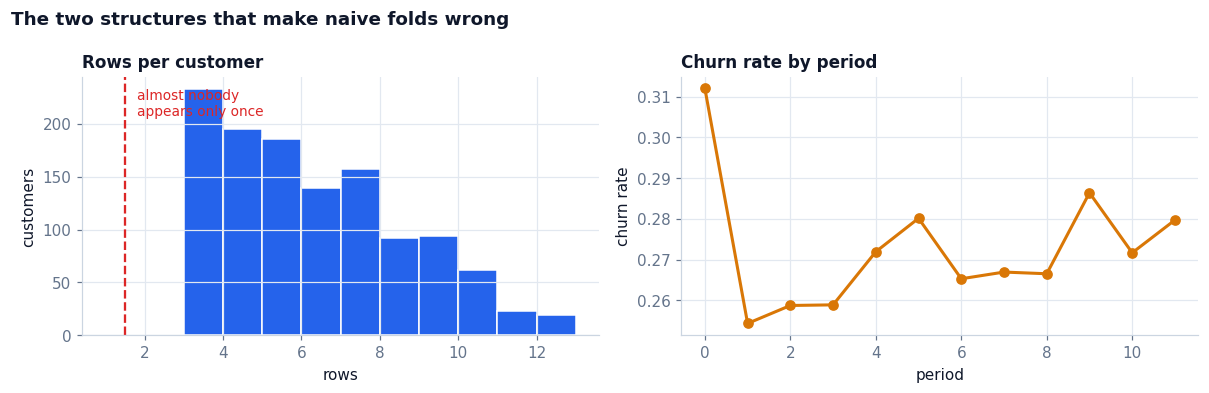

In [5]:
# ============================================================================
# 1.3  The structure that makes folds dangerous, drawn
# ----------------------------------------------------------------------------
# In   : panel
# Out  : rows-per-customer and churn-by-period chart
# Note : Left: almost no customer appears once. Right: the base rate drifts.
#        Those two pictures are the group trap and the time trap.
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

counts = panel.groupby("customer_id").size()
axes[0].hist(counts, bins=range(1, 14), color=COOL, edgecolor="white")
style(axes[0], "Rows per customer", "rows", "customers")
axes[0].axvline(1.5, color=BAD, linestyle="--", linewidth=1.5)
axes[0].text(1.8, axes[0].get_ylim()[1] * 0.85,
             "almost nobody\nappears only once", color=BAD, fontsize=9)

by_period = panel.groupby("period")["churned"].mean()
axes[1].plot(by_period.index, by_period.values, marker="o", color=WARM, linewidth=2)
style(axes[1], "Churn rate by period", "period", "churn rate")

fig.suptitle("The two structures that make naive folds wrong", x=0.005,
             ha="left", fontweight="bold")
plt.tight_layout()
plt.show()

---
<a id="s2"></a>
## 2. The truth, defined once

Deployment for this panel means **two** things at the same time:

- customers the model has never seen
- periods that had not happened when it was trained

So the holdout is both. Everything else in the notebook is development data, and
every scheme is scored by its distance from a model fitted on development and
tested on this holdout.

In [6]:
# ============================================================================
# 2.1  Carve out the truth
# ----------------------------------------------------------------------------
# In   : panel
# Out  : development, holdout
# Note : Unseen customers AND future periods. A fold that respects only one
#        of the two is still not measuring deployment.
# ============================================================================
def split_panel(df, holdout_periods=3, holdout_share=0.30, seed=SEED):
    rng = np.random.default_rng(seed + 977)
    customers = np.sort(df.customer_id.unique())
    held = set(rng.choice(customers, int(len(customers) * holdout_share),
                          replace=False).tolist())
    cutoff = int(df.period.max()) - holdout_periods + 1
    future, in_held = df.period >= cutoff, df.customer_id.isin(held)
    development = df[~future & ~in_held].reset_index(drop=True)
    holdout = df[future & in_held].reset_index(drop=True)
    assert not (set(development.customer_id) & set(holdout.customer_id))
    return development, holdout


dev, out = split_panel(panel)
print(f"development : {len(dev):,} rows   {dev.customer_id.nunique():,} customers"
      f"   periods {sorted(int(p) for p in dev.period.unique())}")
print(f"holdout     : {len(out):,} rows   {out.customer_id.nunique():,} customers"
      f"   periods {sorted(int(p) for p in out.period.unique())}")
print(f"\nshared customers between the two: "
      f"{len(set(dev.customer_id) & set(out.customer_id))}")

development : 3,234 rows   745 customers   periods [0, 1, 2, 3, 4, 5, 6, 7, 8]
holdout     : 660 rows   253 customers   periods [9, 10, 11]

shared customers between the two: 0


In [7]:
# ============================================================================
# 2.2  Score a model against the truth
# ----------------------------------------------------------------------------
# In   : development, holdout
# Out  : TRUTH, the number everything is compared to
# Note : This is the value cross-validation is trying to estimate. On real
#        data you never get to compute it, which is why nobody checks.
# ============================================================================
def booster(seed=SEED):
    return HistGradientBoostingClassifier(max_leaf_nodes=31, learning_rate=0.08,
                                          max_iter=180, early_stopping=False,
                                          random_state=seed)


def linear(select_k=None, C=1.0, seed=SEED):
    steps = [("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]
    if select_k:
        steps.append(("select", SelectKBest(f_classif, k=select_k)))
    steps.append(("model", LogisticRegression(C=C, max_iter=2000, random_state=seed)))
    return Pipeline(steps)


def auc(y, p):
    return np.nan if len(np.unique(y)) < 2 else roc_auc_score(y, p)


def cv_score(est, X, y, splits):
    scores = []
    for tr, te in splits:
        from sklearn.base import clone
        m = clone(est).fit(X.iloc[tr], y[tr])
        scores.append(auc(y[te], m.predict_proba(X.iloc[te])[:, 1]))
    return float(np.nanmean(scores)), scores


def fit_score(est, Xa, ya, Xb, yb):
    from sklearn.base import clone
    return auc(yb, clone(est).fit(Xa, ya).predict_proba(Xb)[:, 1])


Xd, yd = dev[CORE].astype(float), dev.churned.to_numpy()
Xo, yo = out[CORE].astype(float), out.churned.to_numpy()
TRUTH = fit_score(booster(), Xd, yd, Xo, yo)
print(f"TRUTH = {TRUTH:.4f}")
print("\nThis is what every cross-validation scheme below is trying to estimate.")
print("Any scheme scoring above it is flattering the model.")

TRUTH = 0.7279

This is what every cross-validation scheme below is trying to estimate.
Any scheme scoring above it is flattering the model.


---
<a id="s3"></a>
## 3. The structural traps: groups and time

These two come from **how you cut the data**. Section 5 shows why that phrase
matters: structural traps behave completely differently from the statistical
ones as the sample grows.

In [8]:
# ============================================================================
# 3.1  The group trap: the same customer on both sides
# ----------------------------------------------------------------------------
# In   : development
# Out  : stratified vs grouped CV, and what each leaked
# Note : The leakage report counts shared customers per fold rather than
#        trusting the splitter's name.
# ============================================================================
def leak_report(df, splits):
    cust, per = df.customer_id.to_numpy(), df.period.to_numpy()
    rows = []
    for i, (tr, te) in enumerate(splits):
        rows.append({
            "fold": i,
            "pct_test_rows_seen_customer": round(float(np.isin(cust[te], cust[tr]).mean()), 4),
            "train_rows_from_the_future": int((per[tr] >= per[te].min()).sum()),
        })
    return pd.DataFrame(rows)


strat = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xd, yd))
group = list(GroupKFold(5).split(Xd, yd, groups=dev.customer_id.to_numpy()))

results = []
for name, sp in (("StratifiedKFold", strat), ("GroupKFold", group)):
    score, _ = cv_score(booster(), Xd, yd, sp)
    rep = leak_report(dev, sp)
    results.append({"scheme": name, "cv_auc": round(score, 4),
                    "pct_customers_reused": round(rep.pct_test_rows_seen_customer.mean(), 4),
                    "truth": round(TRUTH, 4), "optimism": round(score - TRUTH, 4)})

pd.DataFrame(results)

,scheme,cv_auc,pct_customers_reused,truth,optimism
0,StratifiedKFold,0.7375,0.9616,0.7279,0.0096
1,GroupKFold,0.6948,0.0000,0.7279,-0.0331


In [9]:
# ============================================================================
# 3.2  The time trap: training on periods that had not happened
# ----------------------------------------------------------------------------
# In   : development
# Out  : forward chaining, and both fixes together
# Note : Fixing time alone recovers only part of the error, because the
#        customers are still shared.
# ============================================================================
periods = np.sort(dev.period.unique())


def forward_chaining(df, n_folds=5):
    per = df.period.to_numpy()
    return [(np.flatnonzero(per < p), np.flatnonzero(per == p))
            for p in np.sort(df.period.unique())[-n_folds:]]


def grouped_forward_chaining(df, n_folds=5, seed=SEED):
    rng = np.random.default_rng(seed)
    per, cust = df.period.to_numpy(), df.customer_id.to_numpy()
    custs = np.sort(df.customer_id.unique())
    splits = []
    for p in np.sort(df.period.unique())[-n_folds:]:
        held = set(rng.choice(custs, max(1, len(custs) // 4), replace=False).tolist())
        inh = np.isin(cust, list(held))
        splits.append((np.flatnonzero((per < p) & ~inh), np.flatnonzero((per == p) & inh)))
    return splits


for name, sp in (("ForwardChaining", forward_chaining(dev)),
                 ("GroupedForwardChaining", grouped_forward_chaining(dev))):
    score, _ = cv_score(booster(), Xd, yd, sp)
    rep = leak_report(dev, sp)
    results.append({"scheme": name, "cv_auc": round(score, 4),
                    "pct_customers_reused": round(rep.pct_test_rows_seen_customer.mean(), 4),
                    "truth": round(TRUTH, 4), "optimism": round(score - TRUTH, 4)})

schemes_df = pd.DataFrame(results)
print("Fixing time alone still reuses customers, and the optimism reflects that.\n")
schemes_df

Fixing time alone still reuses customers, and the optimism reflects that.



,scheme,cv_auc,pct_customers_reused,truth,optimism
0,StratifiedKFold,0.7375,0.9616,0.7279,0.0096
1,GroupKFold,0.6948,0.0000,0.7279,-0.0331
2,ForwardChaining,0.7248,0.8285,0.7279,-0.0031
3,GroupedForwardChaining,0.6951,0.0000,0.7279,-0.0328


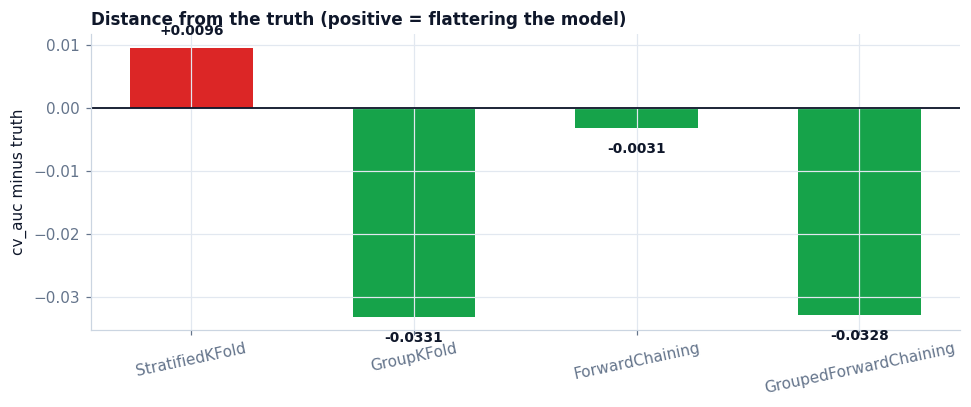

Nothing sits on the line. The careful schemes are conservative,
not accurate, and saying otherwise would be the same mistake inverted.


In [10]:
# ============================================================================
# 3.3  Every scheme against the truth, drawn
# ----------------------------------------------------------------------------
# In   : the scheme results
# Out  : optimism bar chart
# Note : Above the line is flattery, below it is pessimism. Nothing sits on
#        the line, and that is the honest summary.
# ============================================================================
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = [BAD if v > 0 else GOOD for v in schemes_df.optimism]
ax.bar(schemes_df.scheme, schemes_df.optimism, color=colors, width=0.55)
ax.axhline(0, color=INK, linewidth=1.2)
style(ax, "Distance from the truth (positive = flattering the model)", "",
      "cv_auc minus truth")
for i, v in enumerate(schemes_df.optimism):
    ax.text(i, v + (0.002 if v > 0 else -0.004), f"{v:+.4f}",
            ha="center", fontsize=9, fontweight="bold")
ax.tick_params(axis="x", rotation=12)
plt.tight_layout()
plt.show()

print("Nothing sits on the line. The careful schemes are conservative,")
print("not accurate, and saying otherwise would be the same mistake inverted.")

---
<a id="s4"></a>
## 4. The preprocessing trap, and why one number would mislead

Fitting an imputer, a scaler or a feature selector **before** the split lets it
see the validation rows. The imputer and scaler leak a little. Feature selection
leaks a lot, because choosing the 20 columns that correlate best with the target
across all the data guarantees the winners correlate with the validation rows
too.

Everything below uses **grouped** folds, so the group trap is held closed and
this measurement is about preprocessing alone.

In [11]:
# ============================================================================
# 4.1  The preprocessing trap, at one sample size
# ----------------------------------------------------------------------------
# In   : development
# Out  : leaked vs honest CV
# Note : Identical rows, identical folds, identical model. The only
#        difference is whether the selector was fitted before or inside the
#        split.
# ============================================================================
def leaked_matrix(X, y, k):
    Z = X.copy()
    Z[:] = SimpleImputer(strategy="median").fit_transform(Z)
    Z[:] = StandardScaler().fit_transform(Z)
    if k:
        sel = SelectKBest(f_classif, k=min(k, Z.shape[1] - 1)).fit(Z, y)
        Z = Z[Z.columns[sel.get_support()]]
    return Z


XdA = dev[ALL_FEATURES].astype(float)
rows = []
for label, leak, k in (("scale+impute before split", True, None),
                       ("selection before split", True, 20),
                       ("scale+impute inside the fold", False, None),
                       ("selection inside the fold", False, 20)):
    if leak:
        s, _ = cv_score(linear(), leaked_matrix(XdA, yd, k), yd, group)
    else:
        s, _ = cv_score(linear(select_k=k), XdA, yd, group)
    rows.append({"approach": label, "leaked": leak, "cv_auc": round(s, 4)})

prep = pd.DataFrame(rows)
gap = prep.cv_auc[1] - prep.cv_auc[3]
print(f"self-deception from leaking the selector: {gap:+.4f}\n")
prep

self-deception from leaking the selector: +0.0086



,approach,leaked,cv_auc
0,scale+impute before split,True,0.7297
1,selection before split,True,0.7450
2,scale+impute inside the fold,False,0.7298
3,selection inside the fold,False,0.7364


In [12]:
# ============================================================================
# 4.2  The same leak, across sample sizes
# ----------------------------------------------------------------------------
# In   : development
# Out  : self-deception vs rows
# Note : This is where a single number would have been misleading. The
#        answer depends on a variable most write-ups never mention.
# ============================================================================
def subsample(df, n_rows, seed=SEED):
    # Whole customers, never individual rows: sampling rows would split a
    # customer across the boundary and reintroduce the group trap here.
    if n_rows >= len(df):
        return df
    rng = np.random.default_rng(seed)
    custs = np.sort(df.customer_id.unique())
    keep = rng.choice(custs, max(20, int(len(custs) * n_rows / len(df))), replace=False)
    return df[df.customer_id.isin(set(keep.tolist()))].reset_index(drop=True)


SIZES = [200, 400, 900, 2000, len(dev)]
curve = []
for n_rows in SIZES:
    sub = subsample(dev, n_rows)
    Xs, ys = sub[ALL_FEATURES].astype(float), sub.churned.to_numpy()
    if len(np.unique(ys)) < 2 or len(sub) < 60:
        continue
    sp = list(GroupKFold(5).split(Xs, ys, groups=sub.customer_id.to_numpy()))
    a, _ = cv_score(linear(), leaked_matrix(Xs, ys, 20), ys, sp)
    b, _ = cv_score(linear(select_k=20), Xs, ys, sp)
    # the same customer leak, for comparison in section 5
    Xc = sub[CORE].astype(float)
    sk = list(StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xc, ys))
    c, _ = cv_score(booster(), Xc, ys, sk)
    d, _ = cv_score(booster(), Xc, ys, sp)
    curve.append({"rows": len(sub), "selection_leak": round(a - b, 4),
                  "customer_leak": round(c - d, 4)})

curve_df = pd.DataFrame(curve)
print("Selection leakage is severe at a few hundred rows and nearly free at a few\n"
      "thousand. Quoting one number for it quotes a number that depends on a\n"
      "variable most write-ups never mention.\n")
curve_df

Selection leakage is severe at a few hundred rows and nearly free at a few
thousand. Quoting one number for it quotes a number that depends on a
variable most write-ups never mention.



,rows,selection_leak,customer_leak
0,203,0.1446,0.0329
1,362,0.1104,0.0140
2,928,0.0319,0.0875
3,1989,0.0167,0.0596
4,3234,0.0086,0.0427


---
<a id="s5"></a>
## 5. The winner's curse, and two families of trap

Search N candidates, keep the best, quote its CV score. That score is a maximum
over N noisy draws, and a maximum is biased upward **even when every candidate
is equally good**.

To measure that cleanly the candidates must differ in score but not in merit. So
each one keeps all the real columns and adds a different random draw of noise
columns: interchangeable by construction, so the entire spread between them is
luck.

In [13]:
# ============================================================================
# 5.1  The winner's curse
# ----------------------------------------------------------------------------
# In   : development
# Out  : 30 interchangeable candidates, best vs mean
# Note : Every candidate keeps all the real columns and adds different
#        noise, so they are equally good by construction and the spread is
#        pure luck.
# ============================================================================
def candidates(n=30, size=25, seed=SEED):
    rng = np.random.default_rng(seed)
    return [CORE + list(rng.choice(NOISE, size=min(size, len(NOISE)), replace=False))
            for _ in range(n)]


CANDS = candidates()
curse = []
for n_rows in SIZES:
    sub = subsample(dev, n_rows)
    ys = sub.churned.to_numpy()
    if len(np.unique(ys)) < 2 or len(sub) < 60:
        continue
    sp = list(GroupKFold(5).split(sub, ys, groups=sub.customer_id.to_numpy()))
    sc = np.array([cv_score(linear(), sub[c].astype(float), ys, sp)[0] for c in CANDS])
    curse.append({"rows": len(sub), "best_of_30": round(float(sc.max()), 4),
                  "mean_candidate": round(float(sc.mean()), 4),
                  "winners_curse": round(float(sc.max() - sc.mean()), 4)})

curse_df = pd.DataFrame(curse)
curve_df = curve_df.merge(curse_df[["rows", "winners_curse"]], on="rows")
curse_df

,rows,best_of_30,mean_candidate,winners_curse
0,203,0.6461,0.5689,0.0772
1,362,0.6501,0.6092,0.0409
2,928,0.7200,0.7025,0.0176
3,1989,0.7416,0.7374,0.0043
4,3234,0.7426,0.7391,0.0036


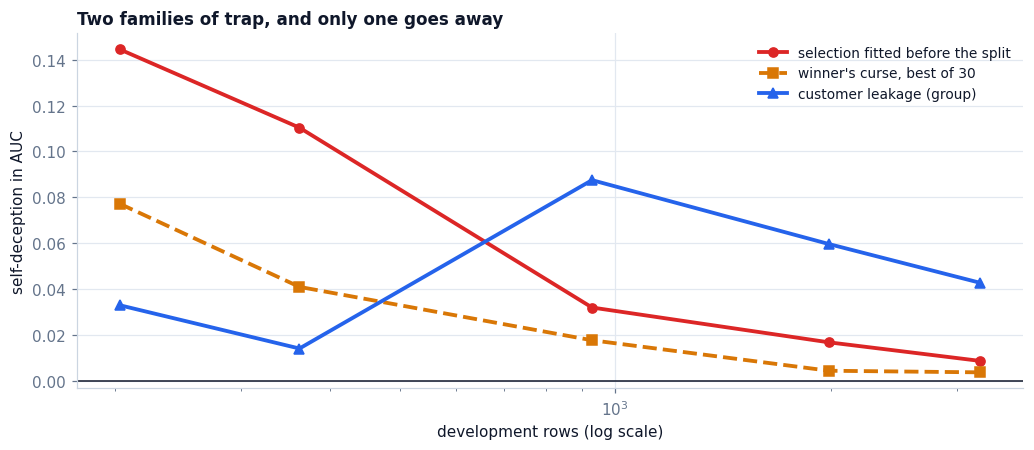

STATISTICAL traps come from how often you look: maxima and correlations
found by chance, so more rows dissolve them.
STRUCTURAL traps come from how you cut: the model is handed information
about the validation rows, and more rows does not stop that.


In [14]:
# ============================================================================
# 5.2  Two families of trap, plotted together
# ----------------------------------------------------------------------------
# In   : the size curves
# Out  : the chart the whole notebook builds to
# Note : Statistical traps dissolve as rows are added. Structural ones do
#        not.
# ============================================================================
fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.plot(curve_df.rows, curve_df.selection_leak, marker="o", color=BAD,
        linewidth=2.5, label="selection fitted before the split")
ax.plot(curve_df.rows, curve_df.winners_curse, marker="s", color=WARM,
        linewidth=2.5, linestyle="--", label="winner's curse, best of 30")
ax.plot(curve_df.rows, curve_df.customer_leak, marker="^", color=COOL,
        linewidth=2.5, label="customer leakage (group)")
ax.axhline(0, color=INK, linewidth=1)
ax.set_xscale("log")
style(ax, "Two families of trap, and only one goes away",
      "development rows (log scale)", "self-deception in AUC")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print("STATISTICAL traps come from how often you look: maxima and correlations")
print("found by chance, so more rows dissolve them.")
print("STRUCTURAL traps come from how you cut: the model is handed information")
print("about the validation rows, and more rows does not stop that.")

---
<a id="s6"></a>
## 6. The trap that is not a bias

The first four traps move the number in a direction. This one does not. A single
CV score is one draw from a distribution, and the distribution is often wide
enough that people read a reshuffle as a result.

Note the splitter below. `GroupKFold` is **deterministic**: it ignores the random
state entirely, so twenty repeats built on it would be the same split twenty
times and would report a standard deviation of exactly zero. That is not
stability, it is a bug, and it is why `StratifiedGroupKFold` appears here.

In [15]:
# ============================================================================
# 6.1  The trap that is not a bias at all
# ----------------------------------------------------------------------------
# In   : development
# Out  : 20 reshuffles of the same CV
# Note : No direction, just spread. It is how a 0.001 difference gets read
#        as a result.
# ============================================================================
A, B = linear(C=1.0), linear(C=0.1)
draws = {"model A (C=1.0)": [], "model B (C=0.1)": []}
for r in range(20):
    sp = list(StratifiedGroupKFold(5, shuffle=True, random_state=SEED + r)
              .split(Xd, yd, groups=dev.customer_id.to_numpy()))
    draws["model A (C=1.0)"].append(cv_score(A, Xd, yd, sp)[0])
    draws["model B (C=0.1)"].append(cv_score(B, Xd, yd, sp)[0])

var_df = pd.DataFrame([
    {"model": k, "mean": round(np.mean(v), 4), "std": round(np.std(v), 4),
     "min": round(np.min(v), 4), "max": round(np.max(v), 4),
     "spread": round(np.max(v) - np.min(v), 4)}
    for k, v in draws.items()])

gap = abs(var_df["mean"][0] - var_df["mean"][1])
wins = int((np.array(draws["model A (C=1.0)"]) > np.array(draws["model B (C=0.1)"])).sum())
print(f"gap between the models : {gap:.4f}")
print(f"widest single spread   : {var_df.spread.max():.4f}")
print(f"A beat B in {wins} of 20 repeats\n")
var_df

gap between the models : 0.0000
widest single spread   : 0.0043
A beat B in 9 of 20 repeats



,model,mean,std,min,max,spread
0,model A (C=1.0),0.7471,0.0013,0.7447,0.749,0.0043
1,model B (C=0.1),0.7471,0.0012,0.7448,0.749,0.0042


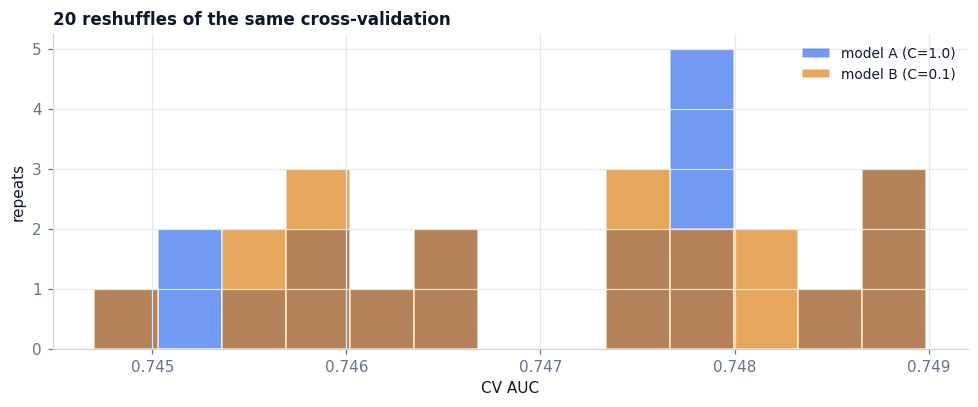

The two distributions sit on top of each other. Any single run could
rank them either way, and a report of one number would not say so.


In [16]:
# ============================================================================
# 6.2  The spread, drawn
# ----------------------------------------------------------------------------
# In   : the repeat draws
# Out  : histogram of the 20 CV scores
# Note : The two models overlap almost completely. Any single run could rank
#        them either way.
# ============================================================================
fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.linspace(min(min(draws.values(), key=min)),
                   max(max(draws.values(), key=max)), 14)
ax.hist(draws["model A (C=1.0)"], bins=bins, alpha=0.65, color=COOL,
        label="model A (C=1.0)", edgecolor="white")
ax.hist(draws["model B (C=0.1)"], bins=bins, alpha=0.65, color=WARM,
        label="model B (C=0.1)", edgecolor="white")
style(ax, "20 reshuffles of the same cross-validation", "CV AUC", "repeats")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print("The two distributions sit on top of each other. Any single run could")
print("rank them either way, and a report of one number would not say so.")

---
<a id="s7"></a>
## 7. What to take away

**A cross-validation score is an estimate, and estimates have errors with
directions.** The only way to know the direction is to hold something back and
subtract. That is one line of code and almost nobody writes it.

**There are two kinds of trap, and they need different responses.**

| | structural | statistical |
|---|---|---|
| caused by | how you split | how often you look |
| examples | groups, time | preprocessing leakage, winner's curse |
| as rows grow | stays | dissolves |
| the fix | change the splitter | nested CV, or resist searching |

More data will not save you from a leaky split. It very nearly does save you
from selection leakage, which is why advice imported from small-sample studies
can be both technically correct and practically irrelevant on a large table.

**The careful scheme is not the true one.** In this panel every correct scheme
overshot into pessimism: GroupKFold landed 0.010 below the truth and grouped
forward chaining 0.027 below. Reading that as "grouped CV gives the right
number" repeats the original mistake with the sign flipped. The honest output is
a range with a direction, not a single decimal.

**One fix is usually not enough.** Forward chaining removed every future training
row and still came back optimistic, because the customers were still shared. The
traps compose, and so must the fixes.

---

### Where to go next

The full project at
[`projects/machine-learning/cross-validation-traps`](https://github.com/genieincodebottle/aiml-companion/tree/main/projects/machine-learning/cross-validation-traps)
runs the same experiments on a larger panel, adds nested CV, and carries the
controls that make the claims falsifiable: set `group_effect` and `drift` to zero
and every gap in this notebook should collapse. If it does not, the measurement
is wrong, not the theory.